# Decision Tree Classifier from Scratch
Visualizing the rectangular decision boundaries created by recursive splitting.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from decision_tree_classifier import MyDecisionTreeClassifier

In [2]:
# Load Iris (2 features)
iris = datasets.load_iris()
X = iris.data[:, 2:] # Petal length and width
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

## 1. Visualizing the 'Boxy' Boundaries
Trees make orthogonal cuts (x > 5, y < 2). This results in decision boundaries that look like steps or boxes.

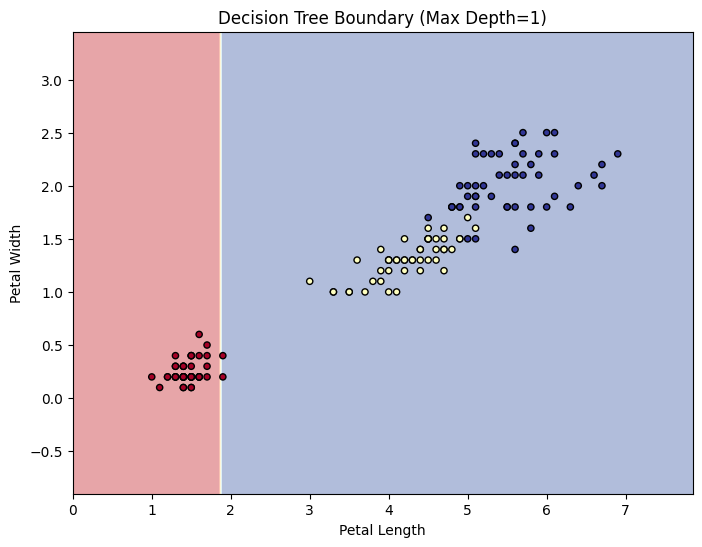

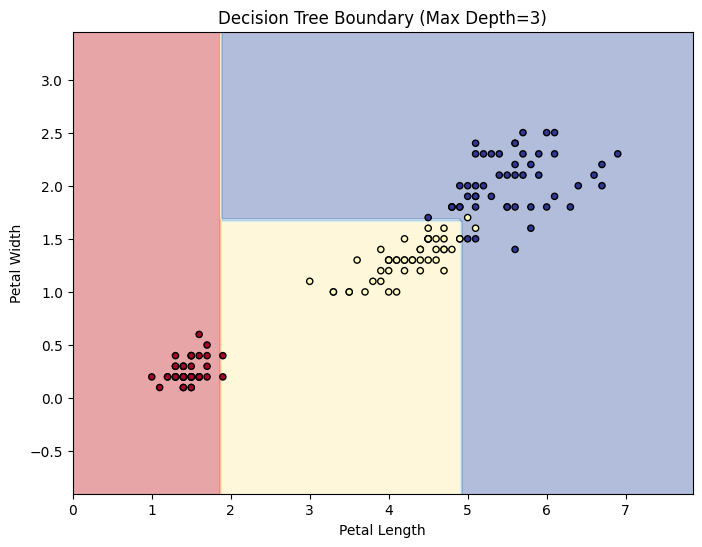

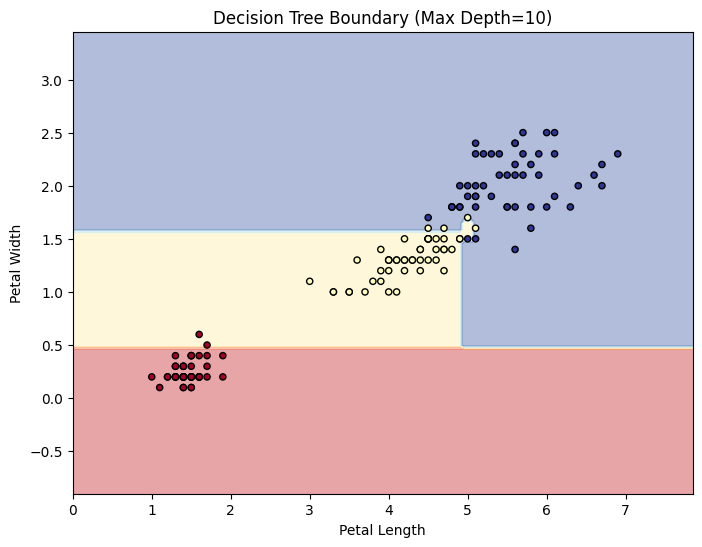

In [3]:
def plot_boundary(depth):
    clf = MyDecisionTreeClassifier(max_depth=depth)
    clf.fit(X_train, y_train)
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap=plt.cm.RdYlBu)
    plt.title(f"Decision Tree Boundary (Max Depth={depth})")
    plt.xlabel("Petal Length")
    plt.ylabel("Petal Width")
    plt.show()

# Depth 1 (Decision Stump - One cut)
plot_boundary(depth=1)

# Depth 3 (More complex boxes)
plot_boundary(depth=3)

# Depth 10 (High complexity - likely overfitting)
plot_boundary(depth=10)